# Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

os.makedirs("outputs", exist_ok=True)

# Load Data

In [2]:
features = pd.read_parquet("data/features/customer_features.parquet")
print(f"Loaded: {features.shape}")

# Numeric clustering columns only
CLUSTER_COLS = [
    "return_rate", "total_orders", "avg_order_value", "max_order_value",
    "avg_days_to_review", "min_days_to_review", "std_days_to_review",
]
# Keep only cols that exist (guards against missing timing data)
CLUSTER_COLS = [c for c in CLUSTER_COLS if c in features.columns]

X_raw = features[CLUSTER_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

Loaded: (2801, 22)


# PCA

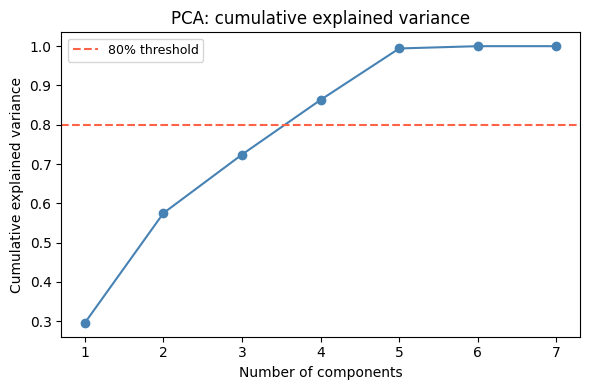

  Keeping 4 components (86.3% variance)

Dominant feature per PCA component:
PC1    avg_days_to_review
PC2       max_order_value
PC3          total_orders
PC4    std_days_to_review
dtype: str


In [3]:
pca_full = PCA(n_components=len(CLUSTER_COLS))
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, "o-", color="steelblue")
ax.axhline(0.80, color="tomato", linestyle="--", label="80% threshold")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA: cumulative explained variance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/pca_variance.png", dpi=150)
plt.show()

# Keep components that explain 80% variance
n_components = int(np.argmax(cumvar >= 0.80)) + 1
print(f"  Keeping {n_components} components ({cumvar[n_components-1]*100:.1f}% variance)")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Print dominant feature per component
loadings = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_COLS,
    columns=[f"PC{i+1}" for i in range(n_components)])
print("\nDominant feature per PCA component:")
print(loadings.abs().idxmax())

# Hierarchical Clustering

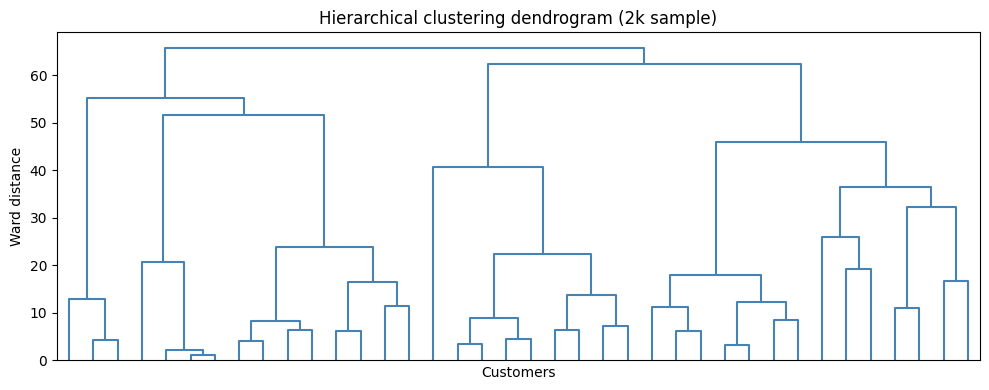

  Silhouette: 0.522  (target > 0.35)
  Davies-Bouldin: 0.742  (lower = better)

  Cluster sizes:
cluster_hier
1       4
2     165
3     253
4     442
5    1937


In [4]:
# Subsample for dendrogram plot only (full linkage is used for labels)
sample_idx = np.random.default_rng(42).choice(len(X_pca), size=min(2000, len(X_pca)), replace=False)
Z_sample = linkage(X_pca[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z_sample, ax=ax, truncate_mode="level", p=5,
           color_threshold=0, above_threshold_color="steelblue",
           no_labels=True)
ax.set_title("Hierarchical clustering dendrogram (2k sample)")
ax.set_xlabel("Customers")
ax.set_ylabel("Ward distance")
plt.tight_layout()
plt.savefig("outputs/dendrogram.png", dpi=150)
plt.show()

# Fit on full data and cut at 5 clusters
N_CLUSTERS = 5
Z_full = linkage(X_pca, method="ward")
hier_labels = fcluster(Z_full, t=N_CLUSTERS, criterion="maxclust")
features["cluster_hier"] = hier_labels

# Silhouette (sample for speed)
sil_sample = min(10000, len(X_pca))
sil_idx = np.random.default_rng(0).choice(len(X_pca), size=sil_sample, replace=False)
sil  = silhouette_score(X_pca[sil_idx], hier_labels[sil_idx])
dbi  = davies_bouldin_score(X_pca[sil_idx], hier_labels[sil_idx])
print(f"  Silhouette: {sil:.3f}  (target > 0.35)")
print(f"  Davies-Bouldin: {dbi:.3f}  (lower = better)")

# Cluster size
print("\n  Cluster sizes:")
print(features["cluster_hier"].value_counts().sort_index().to_string())

# DBSCAN

In [5]:
# Auto-tune epsilon: 95th percentile of 5-NN distances
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
dists, _ = nbrs.kneighbors(X_pca)
eps = float(np.percentile(dists[:, 4], 95))
min_samples = max(5, int(0.005 * len(X_pca)))
print(f"  Auto eps={eps:.3f}, min_samples={min_samples}")

db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
db_labels = db.fit_predict(X_pca)
features["cluster_dbscan"] = db_labels
features["dbscan_noise"]   = (db_labels == -1).astype(int)

n_noise = (db_labels == -1).sum()
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"  DBSCAN clusters: {n_clusters_db}  |  Noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

  Auto eps=0.788, min_samples=14
  DBSCAN clusters: 5  |  Noise points: 195 (7.0%)


# Centroid Distance Features

In [6]:
# Centroid = mean of PCA coords per hierarchical cluster
centroids = np.array([
    X_pca[hier_labels == k].mean(axis=0)
    for k in range(1, N_CLUSTERS + 1)
])
dists_to_centroids = euclidean_distances(X_pca, centroids)
for i in range(N_CLUSTERS):
    features[f"dist_to_cluster_{i+1}"] = dists_to_centroids[:, i]

# Cluster Profiles

In [ ]:
profile_cols = CLUSTER_COLS + ["dbscan_noise"]

profiles = (features
    .groupby("cluster_hier")[profile_cols]
    .mean()
    .round(3))
profiles["n_customers"] = features.groupby("cluster_hier").size()

print("\nCluster profiles (mean values):")
print(profiles.to_string())

rank_by_rate = profiles["return_rate"].rank(ascending=False).astype(int)
CLUSTER_NAMES = {
    1: "Policy Abusers",
    2: "Occasional Dissatisfied",
    3: "High-Value Fast Returners",
    4: "Fraud / Serial Abusers",
    5: "Loyal Low-Risk",
}

# Fill remaining
remaining = [c for c in range(1, N_CLUSTERS+1) if c not in CLUSTER_NAMES]
extras = ["High-Value Abusers", "Slow Dissatisfied", "New / Uncertain"]
for c, name in zip(remaining, extras):
    CLUSTER_NAMES[c] = name
features["cluster_name"] = features["cluster_hier"].map(CLUSTER_NAMES)

profiles.to_csv("outputs/cluster_profiles.csv")
features.to_parquet("data/features/customer_features_clustered.parquet", index=False)

print(f"\nSaved: data/features/customer_features_clustered.parquet")
print(f"       outputs/cluster_profiles.csv")
print(f"\nCluster name mapping: {CLUSTER_NAMES}")


Cluster profiles (mean values):
              return_rate  total_orders  avg_order_value  max_order_value  avg_days_to_review  min_days_to_review  std_days_to_review  dbscan_noise  n_customers
cluster_hier                                                                                                                                                    
1                   0.300         2.750          107.694          169.165              16.250              11.750               6.364         1.000            4
2                   0.186         2.127          125.284          164.777              11.015              11.012               0.004         0.485          165
3                   0.095         2.174          454.299          663.537               0.233               0.233               0.000         0.261          253
4                   0.655         2.027          136.338          176.866               0.181               0.176               0.006         0.038          442
5